Shape: (39, 8)
Index(['holiday', 'temp', 'rain_1h', 'snow_1h', 'clouds_all', 'weather_main',
       'date_time', 'traffic_volume'],
      dtype='object')
X shape: (39, 4)
MSE: 101004.75324999995


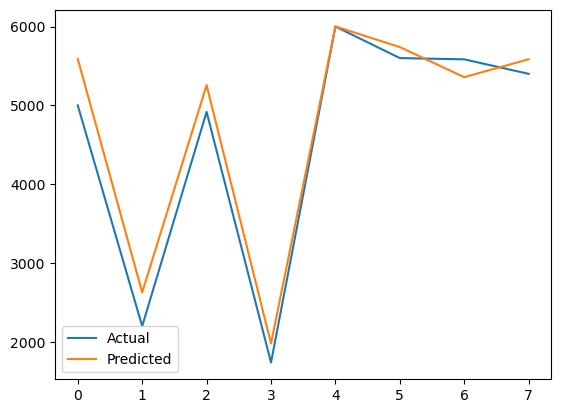

In [5]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error

# Load file
df = pd.read_csv("C:/Users/atula/Downloads/traffic.csv")

# Clean column names (VERY IMPORTANT)
df.columns = df.columns.str.strip()

print("Shape:", df.shape)
print(df.columns)

# Convert datetime
df['date_time'] = pd.to_datetime(df['date_time'], errors='coerce')

# Create features
df['hour'] = df['date_time'].dt.hour
df['day'] = df['date_time'].dt.dayofweek

# Fill missing values
df = df.fillna(0)

# Select features
X = df[['hour', 'day', 'temp', 'rain_1h']]
y = df['traffic_volume']

print("X shape:", X.shape)

# SAFETY CHECK
if len(X) == 0:
    print("ERROR: Dataset is empty ❌")
else:
    # Split
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42
    )

    # Train
    model = RandomForestRegressor()
    model.fit(X_train, y_train)

    # Predict
    pred = model.predict(X_test)

    # Evaluate
    print("MSE:", mean_squared_error(y_test, pred))

    # Plot
    plt.plot(y_test.values, label="Actual")
    plt.plot(pred, label="Predicted")
    plt.legend()
    plt.show()